# Titanic Dataset - Exploratory Data Analysis
This notebook performs EDA on the Titanic dataset to identify patterns, trends, and anomalies, using Pandas, Matplotlib, and Seaborn.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from fpdf import FPDF

In [52]:
df = pd.read_csv("train.csv")

In [53]:
# Summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [54]:
os.makedirs("plots", exist_ok=True)

In [55]:
print("First 5 rows:\n", df.head())
print("\nInfo:\n")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

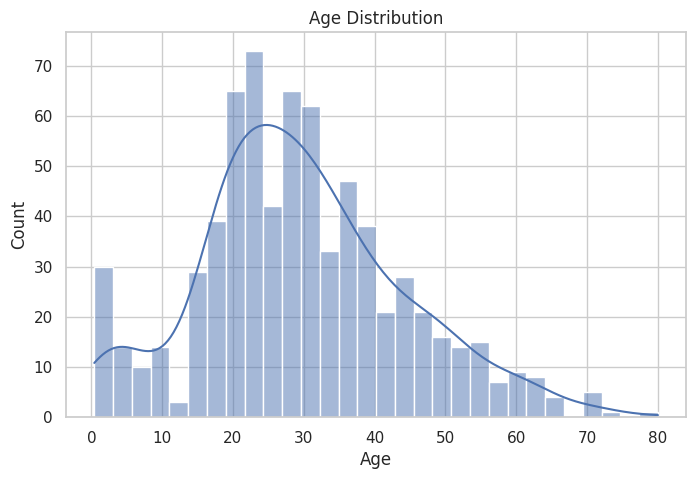

In [56]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.savefig("plots/age_distribution.png")
plt.show()


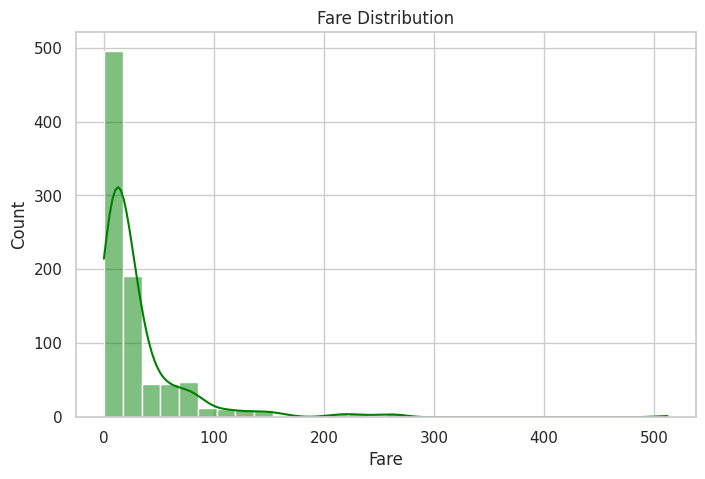

In [57]:
# Fare distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True, color='green')
plt.title("Fare Distribution")
plt.savefig("plots/fare_distribution.png")
plt.show()


/tmp/ipython-input-4046693971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette="Set2")


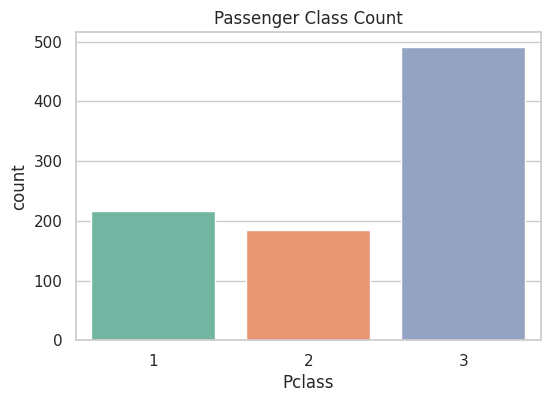

In [58]:
# Passenger class count
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df, palette="Set2")
plt.title("Passenger Class Count")
plt.savefig("plots/passenger_class_count.png")
plt.show()

/tmp/ipython-input-482704018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette="Set1")


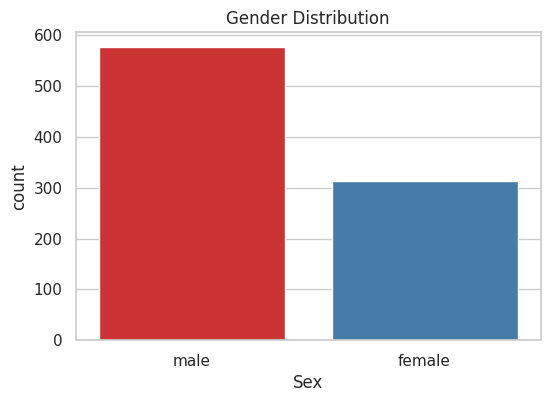

In [59]:
# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df, palette="Set1")
plt.title("Gender Distribution")
plt.savefig("plots/gender_distribution.png")
plt.show()

/tmp/ipython-input-2420291978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette="coolwarm")


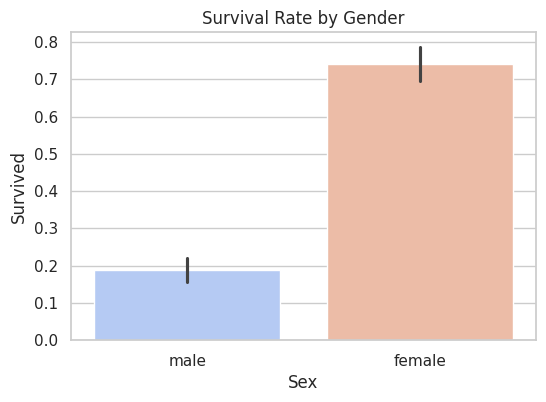

In [60]:
# Survival rate by gender
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df, palette="coolwarm")
plt.title("Survival Rate by Gender")
plt.savefig("plots/survival_by_gender.png")
plt.show()

/tmp/ipython-input-1778661360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette="viridis")


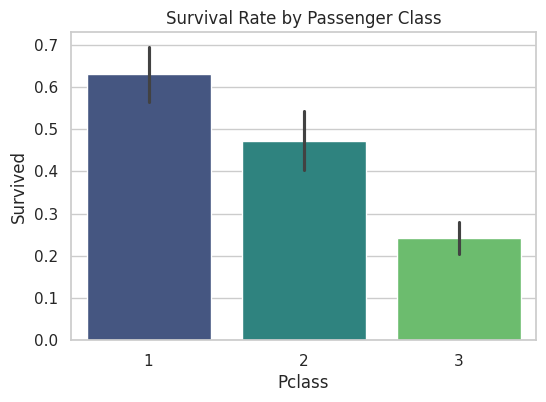

In [61]:
# Survival rate by class
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df, palette="viridis")
plt.title("Survival Rate by Passenger Class")
plt.savefig("plots/survival_by_class.png")
plt.show()

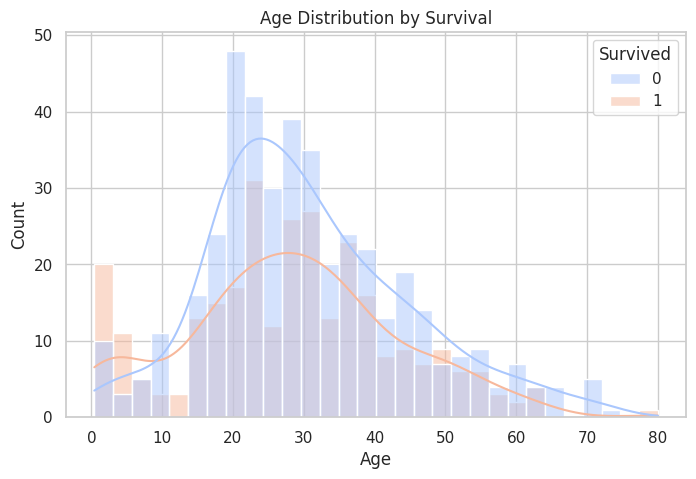

In [62]:
# Age vs Survival
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, palette="coolwarm")
plt.title("Age Distribution by Survival")
plt.savefig("plots/age_vs_survival.png")
plt.show()

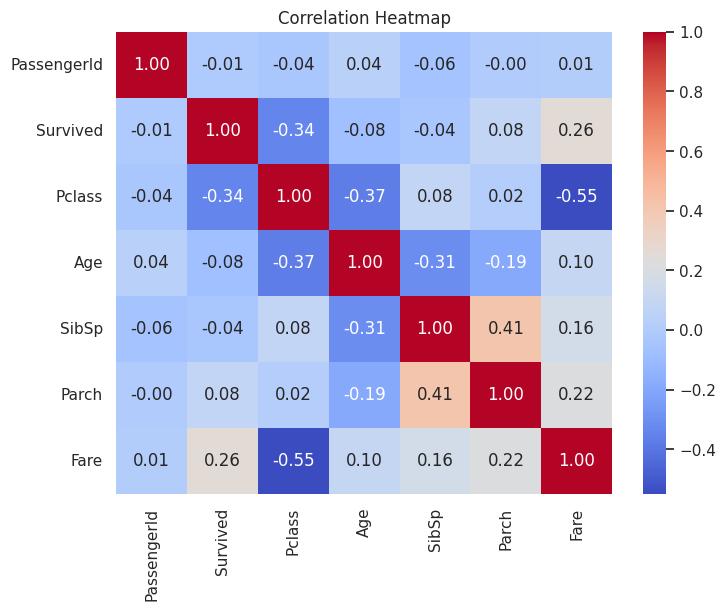

In [63]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("plots/correlation_heatmap.png")
plt.show()

In [64]:

class PDF(FPDF):
    def header(self):
        self.set_font("Arial", 'B', 16)
        self.cell(0, 10, "Titanic Dataset - Exploratory Data Analysis", ln=True, align="C")
        self.ln(10)

    def chapter_title(self, title):
        self.set_font("Arial", 'B', 14)
        self.cell(0, 10, title, ln=True)
        self.ln(4)

    def chapter_body(self, text):
        self.set_font("Arial", '', 12)
        self.multi_cell(0, 7, text)
        self.ln()

    def add_image(self, image_path, w=150):
        self.image(image_path, w=w)
        self.ln()

In [65]:
pdf = PDF()
pdf.set_auto_page_break(auto=True, margin=15)


In [66]:
pdf.add_page()
pdf.set_font("Arial", 'B', 20)
pdf.cell(0, 10, "Exploratory Data Analysis Report", ln=True, align="C")
pdf.set_font("Arial", '', 14)
pdf.cell(0, 10, "Titanic Dataset", ln=True, align="C")
pdf.ln(20)

In [67]:
pdf.add_page()
pdf.chapter_title("1. Dataset Overview")
pdf.chapter_body(f"Total Rows: {df.shape[0]}\nTotal Columns: {df.shape[1]}")
pdf.chapter_body("This dataset contains passenger details like age, gender, fare, class, and survival status.")


In [68]:
pdf.chapter_title("2. Univariate Analysis")
pdf.add_image("plots/age_distribution.png")
pdf.chapter_body("Most passengers were between 20-40 years old, with fewer elderly passengers.")
pdf.add_image("plots/fare_distribution.png")
pdf.chapter_body("Fare distribution is right-skewed, with some very high outliers.")
pdf.add_image("plots/passenger_class_count.png")
pdf.chapter_body("Third class had the most passengers, followed by first and second class.")
pdf.add_image("plots/gender_distribution.png")
pdf.chapter_body("There were more male passengers than female passengers.")


In [69]:
pdf.chapter_title("3. Bivariate Analysis")
pdf.add_image("plots/survival_by_gender.png")
pdf.chapter_body("Women had a significantly higher survival rate than men.")
pdf.add_image("plots/survival_by_class.png")
pdf.chapter_body("First-class passengers had the highest survival rate.")
pdf.add_image("plots/age_vs_survival.png")
pdf.chapter_body("Children and younger passengers had slightly better chances of survival.")


In [70]:
pdf.chapter_title("4. Correlation Analysis")
pdf.add_image("plots/correlation_heatmap.png")
pdf.chapter_body("Passenger class and fare are strongly correlated. Survival shows moderate correlation with gender and class.")


In [71]:
pdf.chapter_title("5. Insights & Conclusion")
pdf.chapter_body("- Women had higher survival chances.\n- First-class passengers were more likely to survive.\n- Fare and class strongly influence survival chances.")


In [72]:
pdf.output("Titanic_EDA_Report.pdf")


''

In [73]:
print("✅ EDA complete. Plots saved in 'plots' folder. Report saved as 'Titanic_EDA_Report.pdf'.")

✅ EDA complete. Plots saved in 'plots' folder. Report saved as 'Titanic_EDA_Report.pdf'.
